# **PROYECTO: INTRODUCCIÓN AL ANÁLISIS ESTADÍSTICO**

Una vez visto el ***Módulo 2: Fundamentos Estadísticos***, se presenta la siguiente actividad para que el alumnado pueda poner a prueba lo aprendido durante este módulo.

Dentro de la siguiente dinámica, realizar el siguiente **análisis exploratorio con aprendizaje estadístico** de cualquier dataset proveniente de la librería de ***Seaborn*** que no haya sido utilizado.

Se sugiere los siguientes puntos para llevar a cabo lo anterior:

*   Realizar un **análisis descriptivo** para comprender comportamiento de la descripción de los datos a través de resúmenes.
*   Realizar un **aprendizaje estadístico** para predecir comportamientos lineales de datos a través de la regresión lineal simple.

## 1. Selección del dataset

Se utilizará el dataset **`mpg`** (Miles Per Gallon) de Seaborn, que contiene información de 398 automóviles fabricados entre 1970 y 1982, incluyendo características técnicas (cilindros, desplazamiento, caballos de fuerza, peso, aceleración) y de eficiencia de combustible (millas por galón).

**Pregunta de investigación:** ¿Es posible predecir el rendimiento de combustible (`mpg`) de un automóvil a partir de su peso (`weight`)?

## 2. Importación de librerías

In [25]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


## 3. Carga y exploración inicial del dataset

Es una base de datos que contiene información sobre modelos de automóviles y su rendimiento de combustible, Cuántas millas por galón consumen en ciudad y carretera

In [26]:
df = sns.load_dataset('mpg')
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [27]:
print('Dimensiones del dataset:', df.shape)
print('\nTipos de datos:')
print(df.dtypes)
print('\nValores nulos por columna:')
print(df.isnull().sum())

Dimensiones del dataset: (398, 9)

Tipos de datos:
mpg             float64
cylinders         int64
displacement    float64
horsepower      float64
weight            int64
acceleration    float64
model_year        int64
origin           object
name             object
dtype: object

Valores nulos por columna:
mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
name            0
dtype: int64


In [28]:
# Eliminamos las filas con valores nulos
df = df.dropna().reset_index(drop=True)
print('Dimensiones tras limpieza:', df.shape)

Dimensiones tras limpieza: (392, 9)


## 4. Análisis descriptivo

Se generan resúmenes estadísticos de las variables numéricas para entender su comportamiento central, dispersión y rango.

In [29]:
df.describe().round(2)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
count,392.00,392.00,392.00,392.00,392.00,392.00,392.00
mean,23.45,5.47,194.41,104.47,2977.58,15.54,75.98
std,7.81,1.71,104.64,38.49,849.40,2.76,3.68
min,9.00,3.00,68.00,46.00,1613.00,8.00,70.00
25%,17.00,4.00,105.00,75.00,2225.25,13.78,73.00
50%,22.75,4.00,151.00,93.50,2803.50,15.50,76.00
75%,29.00,8.00,275.75,126.00,3614.75,17.02,79.00
max,46.60,8.00,455.00,230.00,5140.00,24.80,82.00


### 4.1 Medidas de tendencia central y dispersión (variables clave)

In [30]:
variables = ['mpg', 'weight', 'horsepower', 'displacement', 'acceleration']
resumen = pd.DataFrame({
    'Media': df[variables].mean(),
    'Mediana': df[variables].median(),
    'Moda': df[variables].mode().iloc[0],
    'Desv. Estándar': df[variables].std(),
    'Varianza': df[variables].var(),
    'Mínimo': df[variables].min(),
    'Máximo': df[variables].max(),
    'Rango': df[variables].max() - df[variables].min(),
    'IQR': df[variables].quantile(0.75) - df[variables].quantile(0.25),
    'Asimetría': df[variables].skew(),
    'Curtosis': df[variables].kurt()
}).round(3)
resumen

,Media,Mediana,Moda,Desv. Estándar,Varianza,Mínimo,Máximo,Rango,IQR,Asimetría,Curtosis
mpg,23.446,22.75,13.0,7.805,60.918,9.0,46.6,37.6,12.00,0.457,-0.516
weight,2977.584,2803.50,1985.0,849.403,721484.709,1613.0,5140.0,3527.0,1389.50,0.520,-0.809
horsepower,104.469,93.50,150.0,38.491,1481.569,46.0,230.0,184.0,51.00,1.087,0.697
displacement,194.412,151.00,97.0,104.644,10950.368,68.0,455.0,387.0,170.75,0.702,-0.778
acceleration,15.541,15.50,14.5,2.759,7.611,8.0,24.8,16.8,3.25,0.292,0.444


**Observaciones:**
- El mpg promedio es  de 23.45 millas por galón, con desviación estándar de 7.8.
- El weight promedio es 2977 libras, con un rango amplio (1613–5140), lo que sugiere gran variabilidad entre vehículos.
- La asimetría positiva en horsepower y displacement indica colas hacia la derecha (autos con motores potentes son menos frecuentes).

### 4.2 Distribución de variables

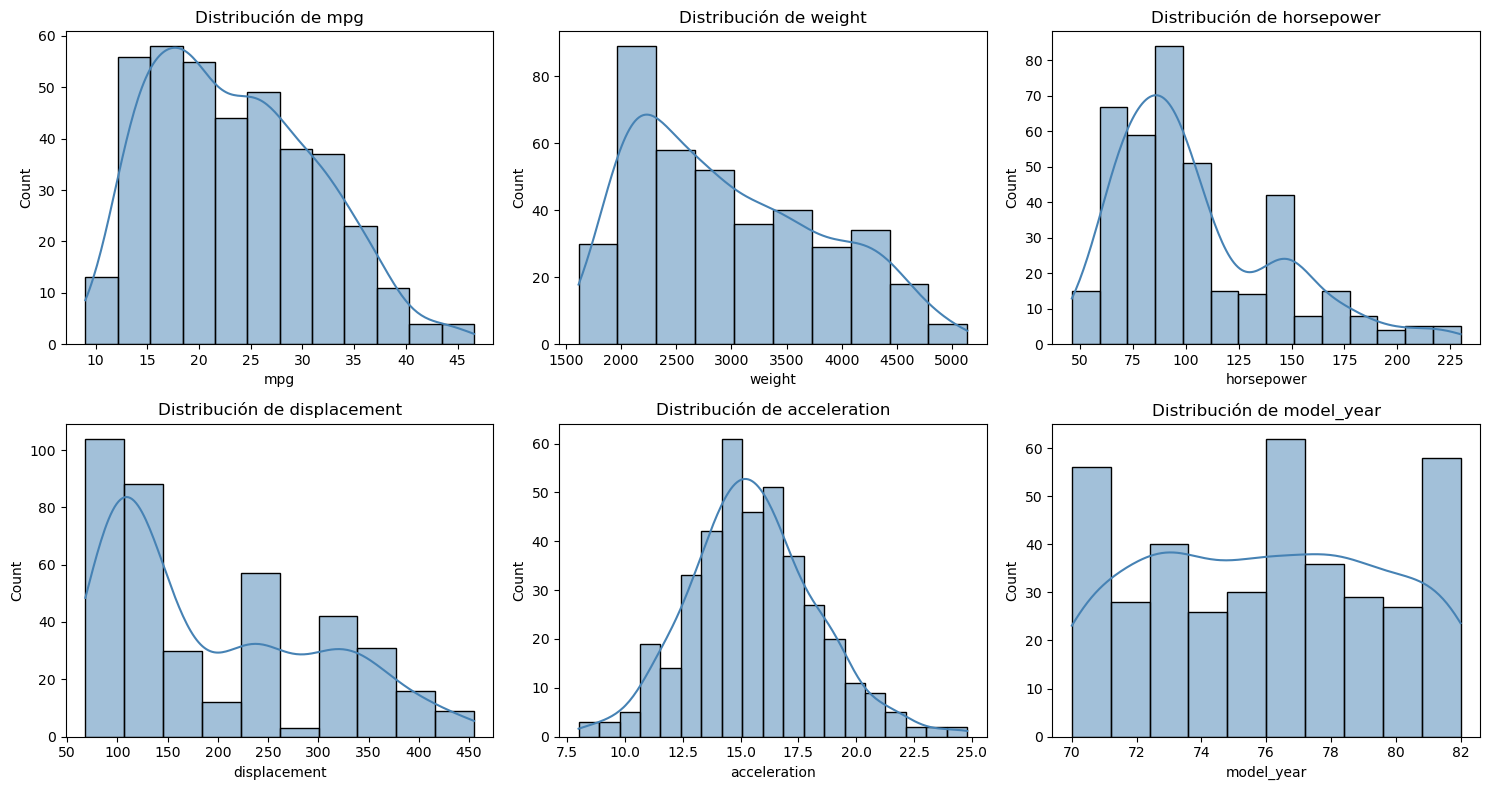

In [31]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), variables + ['model_year']):
    sns.histplot(df[col], kde=True, ax=ax, color='steelblue')
    ax.set_title(f'Distribución de {col}')
plt.tight_layout()
plt.show()

### 4.3 Detección de valores atípicos

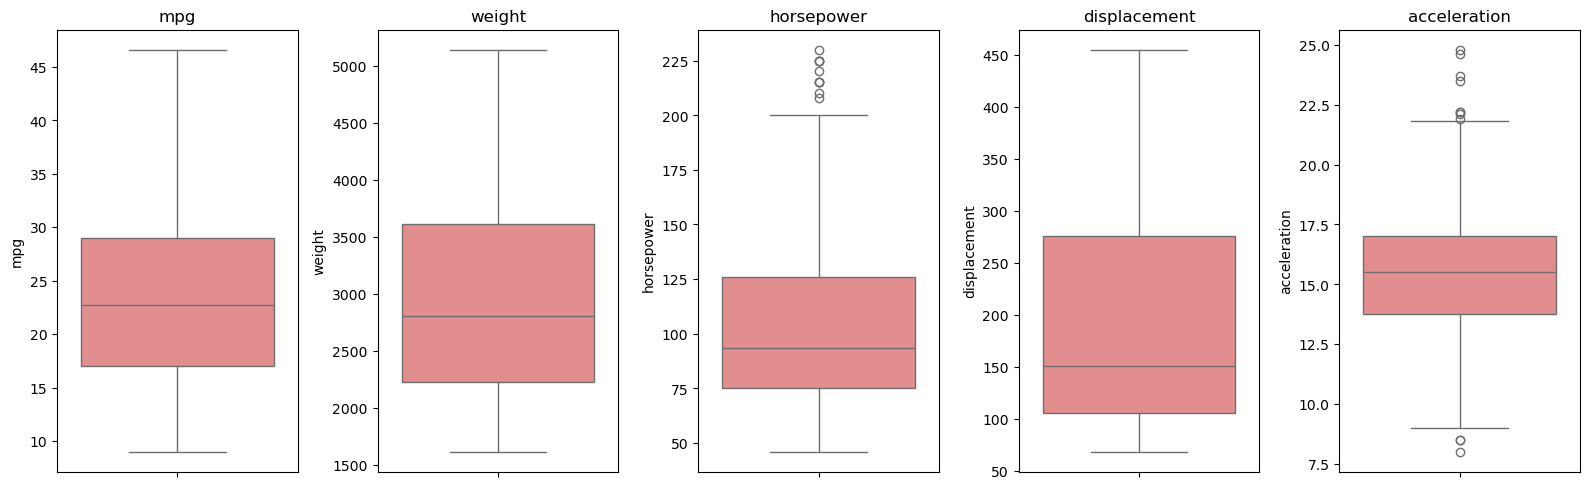

In [32]:
fig, axes = plt.subplots(1, len(variables), figsize=(16, 5))
for ax, col in zip(axes, variables):
    sns.boxplot(y=df[col], ax=ax, color='lightcoral')
    ax.set_title(col)
plt.tight_layout()
plt.show()

### 4.4 Análisis por categorías

In [33]:
df.groupby('origin')[['mpg', 'weight', 'horsepower']].mean().round(2)

,mpg,weight,horsepower
origin,,,
europe,27.60,2433.47,80.56
japan,30.45,2221.23,79.84
usa,20.03,3372.49,119.05


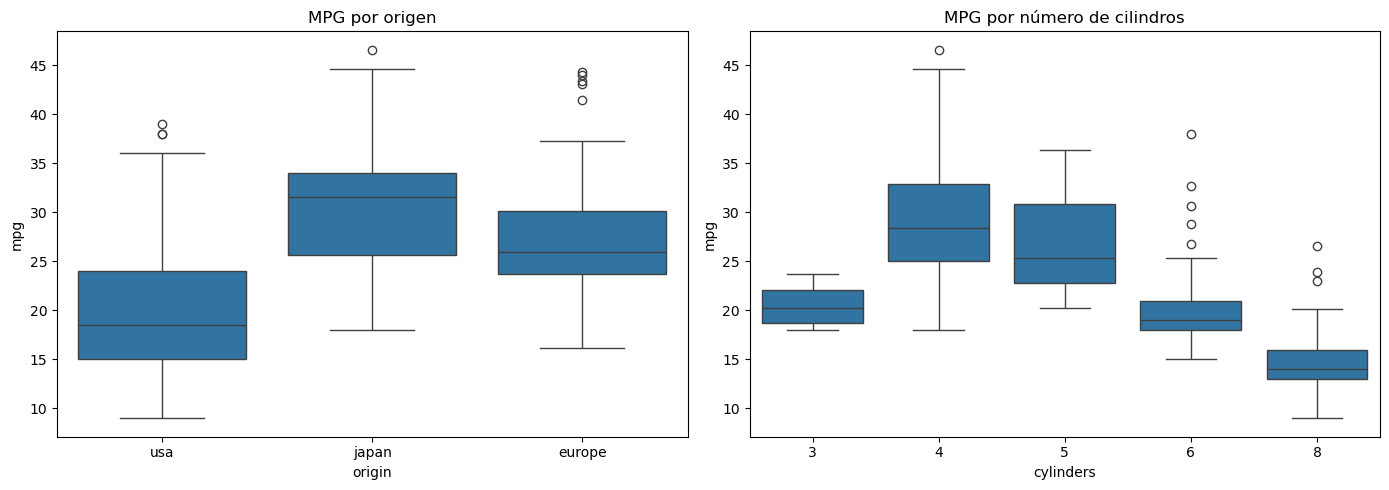

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df, x='origin', y='mpg', ax=axes[0])
axes[0].set_title('MPG por origen')
sns.boxplot(data=df, x='cylinders', y='mpg', ax=axes[1])
axes[1].set_title('MPG por número de cilindros')
plt.tight_layout()
plt.show()

### 4.5 Matriz de correlación

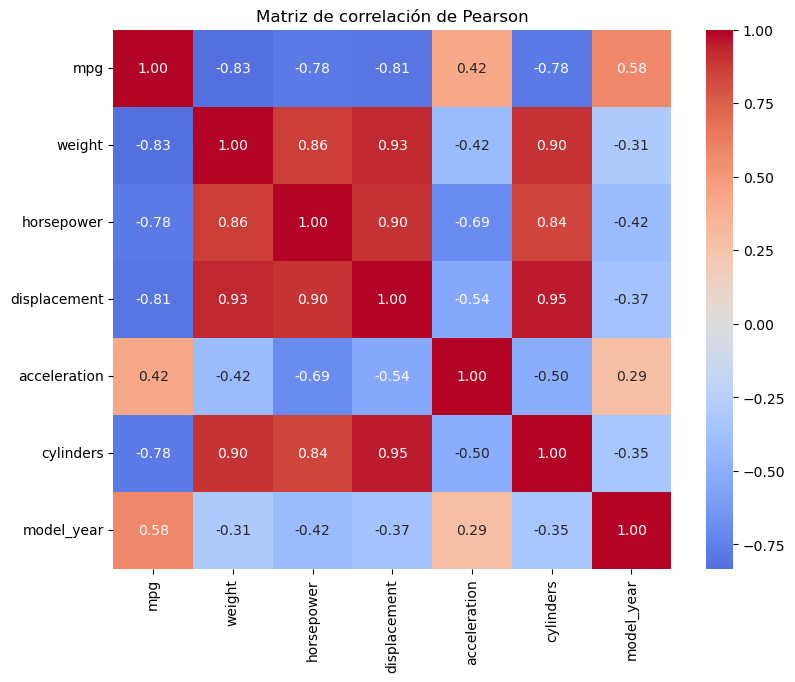

In [35]:
corr = df[variables + ['cylinders', 'model_year']].corr()
plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', center=0)
plt.title('Matriz de correlación de Pearson')
plt.show()

**Interpretación:** mpg muestra correlación negativa fuerte con weight (-0.83), horsepower (-0.78) y displacement (-0.81). Esto justifica usar weight como predictor de mpg mediante regresión lineal simple.

## 5. Regresión Lineal Simple

**Modelo propuesto:** $\hat{mpg} = \beta_0 + \beta_1 \cdot weight$

### 5.1 Visualización preliminar de la relación

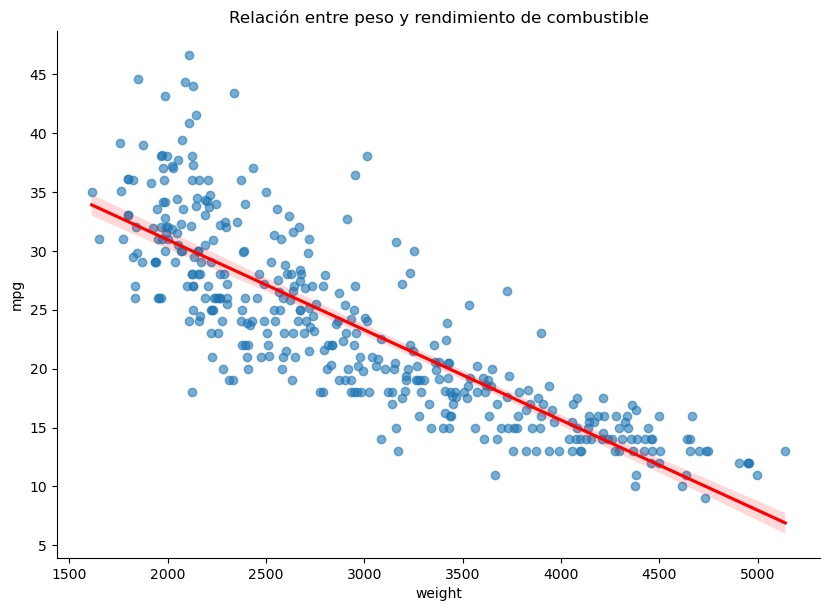

In [36]:
sns.lmplot(data=df, x='weight', y='mpg', height=6, aspect=1.4,
           line_kws={'color': 'red'}, scatter_kws={'alpha': 0.6})
plt.title('Relación entre peso y rendimiento de combustible')
plt.show()

### 5.2 División en entrenamiento y prueba

In [37]:
X = df[['weight']].values
y = df['mpg'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(f'Entrenamiento: {X_train.shape[0]} obs.')
print(f'Prueba: {X_test.shape[0]} obs.')

Entrenamiento: 313 obs.
Prueba: 79 obs.


### 5.3 Entrenamiento del modelo

In [38]:
modelo = LinearRegression()
modelo.fit(X_train, y_train)

beta_0 = modelo.intercept_
beta_1 = modelo.coef_[0]

print(f'Intercepto (β0): {beta_0:.4f}')
print(f'Pendiente   (β1): {beta_1:.6f}')
print(f'\nEcuación: mpg = {beta_0:.3f} + ({beta_1:.6f}) * weight')

Intercepto (β0): 47.2005
Pendiente   (β1): -0.007904

Ecuación: mpg = 47.201 + (-0.007904) * weight


**Interpretación de los coeficientes:**
- $\beta_1 \approx -0.0079$: por cada libra adicional de peso, el rendimiento disminuye 0.0079 mpg (o 7.9 mpg por cada 1000 libras).
- $\beta_0 \approx 47.2$: rendimiento teórico cuando el peso es 0

### 5.4 Evaluación del modelo

In [39]:
y_pred_train = modelo.predict(X_train)
y_pred_test  = modelo.predict(X_test)

metricas = pd.DataFrame({
    'Entrenamiento': [
        mean_absolute_error(y_train, y_pred_train),
        mean_squared_error(y_train, y_pred_train),
        np.sqrt(mean_squared_error(y_train, y_pred_train)),
        r2_score(y_train, y_pred_train)
    ],
    'Prueba': [
        mean_absolute_error(y_test, y_pred_test),
        mean_squared_error(y_test, y_pred_test),
        np.sqrt(mean_squared_error(y_test, y_pred_test)),
        r2_score(y_test, y_pred_test)
    ]
}, index=['MAE', 'MSE', 'RMSE', 'R²']).round(4)
metricas

,Entrenamiento,Prueba
MAE,3.2855,3.4641
MSE,19.0451,17.6934
RMSE,4.3641,4.2064
R²,0.6982,0.6533


### 5.5 Significancia estadística

In [40]:
slope, intercept, r_value, p_value, std_err = stats.linregress(df['weight'], df['mpg'])
print(f'Pendiente:           {slope:.6f}')
print(f'Intercepto:          {intercept:.4f}')
print(f'Coef. correlación r: {r_value:.4f}')
print(f'R²:                  {r_value**2:.4f}')
print(f'p-value:             {p_value:.4e}')
print(f'Error estándar:      {std_err:.6f}')

Pendiente:           -0.007647
Intercepto:          46.2165
Coef. correlación r: -0.8322
R²:                  0.6926
p-value:             6.0153e-102
Error estándar:      0.000258


Como `p-value` ≈ 0 (< 0.05), se rechaza H₀: $\beta_1 = 0$. Existe evidencia estadística de que el peso influye significativamente sobre el rendimiento de combustible.

### 5.6 Análisis de residuos

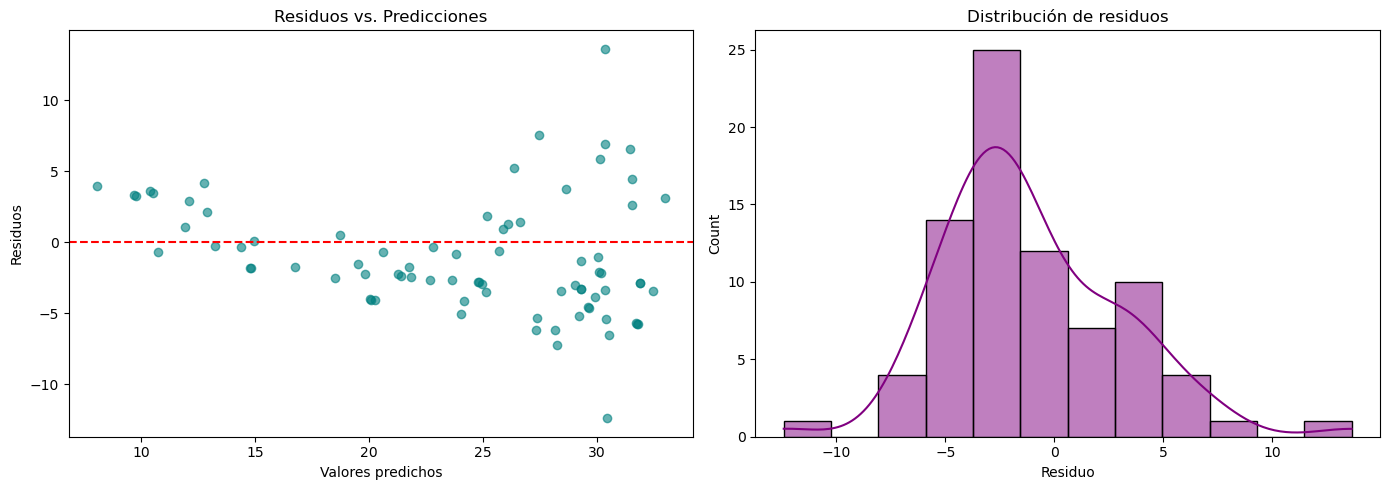

Shapiro-Wilk: estadístico=0.9554, p-value=0.0076


In [41]:
residuos = y_test - y_pred_test

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(y_pred_test, residuos, alpha=0.6, color='teal')
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Valores predichos')
axes[0].set_ylabel('Residuos')
axes[0].set_title('Residuos vs. Predicciones')

sns.histplot(residuos, kde=True, ax=axes[1], color='purple')
axes[1].set_title('Distribución de residuos')
axes[1].set_xlabel('Residuo')
plt.tight_layout()
plt.show()

# Test de normalidad (Shapiro-Wilk)
stat, p = stats.shapiro(residuos)
print(f'Shapiro-Wilk: estadístico={stat:.4f}, p-value={p:.4f}')

### 5.7 Predicciones con nuevos datos

In [42]:
nuevos_pesos = np.array([[1800], [2500], [3200], [4000], [4800]])
predicciones = modelo.predict(nuevos_pesos)

pd.DataFrame({
    'Peso (lb)': nuevos_pesos.flatten(),
    'MPG predicho': predicciones.round(2)
})

,Peso (lb),MPG predicho
0,1800,32.97
1,2500,27.44
2,3200,21.91
3,4000,15.59
4,4800,9.26


## 6. Conclusiones

1. **Análisis descriptivo:** El dataset mpg contiene 392 observaciones útiles tras eliminar nulos. La variable objetivo mpg tiene media 23.4 y desviación estándar 7.8, con leve asimetría positiva. Existen diferencias claras por origin y cylinders: vehículos europeos y japoneses muestran mejor rendimiento que los americanos.

2. **Correlaciones:** mpg se correlaciona negativamente y de forma fuerte con weight, horsepower y displacement, lo que confirma intuitivamente que vehículos más pesados/potentes consumen más combustible.

3. **Regresión lineal simple (weight → mpg):**
   - El modelo alcanza un **R² ≈ 0.69** en prueba, explicando cerca del 69 % de la variabilidad del rendimiento.
   - El coeficiente es estadísticamente significativo.
   - Los residuos muestran cierta curvatura, lo que sugiere que una relación **no lineal** (o un modelo de regresión múltiple incluyendo horsepower, displacement y model_year) podría capturar mejor el comportamiento.
